In [4]:
print("STEP 1: Imports")

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight

print("STEP 1 DONE\n")

STEP 1: Imports
STEP 1 DONE



In [10]:
print("STEP 2: Load phase1 only")

train_df = pd.read_csv("phase1_label.csv")

print("Total rows (raw):", len(train_df))
print(train_df.head())
print("STEP 2 DONE\n")

STEP 2: Load phase1 only
Total rows (raw): 8288
             ID labels         split  Unnamed: 3  Unnamed: 4  Unnamed: 5
0  00185772.jpg     BL  phase1_train         NaN         NaN         NaN
1  00185756.jpg    BNE  phase1_train         NaN         NaN         NaN
2  00185821.jpg    BNE  phase1_train         NaN         NaN         NaN
3  00185845.jpg    BNE  phase1_train         NaN         NaN         NaN
4  00185854.jpg    BNE  phase1_train         NaN         NaN         NaN
STEP 2 DONE



In [15]:
print("STEP 3: Remove duplicates by ID")

train_df = train_df.drop_duplicates(subset="ID")

print("Total unique images:", len(train_df))
print("STEP 3 DONE\n")

STEP 3: Remove duplicates by ID
Total unique images: 8288
STEP 3 DONE



In [19]:
print("STEP 4: Map labels")

def map_to_3class(label):
    mature = ["SNE", "LY", "MO", "EO", "BA", "BNE"]
    immature = ["MY", "MMY", "PMY", "BL"]
    rare = ["VLY", "PLY", "PC"]

    if label in mature:
        return "MATURE"
    elif label in immature:
        return "IMMATURE"
    elif label in rare:
        return "RARE"
    else:
        return "OTHER"

train_df["label3"] = train_df["labels"].apply(map_to_3class)

# remove OTHER
train_df = train_df[train_df["label3"] != "OTHER"]

print(train_df["label3"].value_counts())
print("STEP 4 DONE\n")

STEP 4: Map labels
label3
MATURE      7364
IMMATURE     820
RARE         104
Name: count, dtype: int64
STEP 4 DONE



In [22]:
print("STEP 5: Create paths")

BASE_PATH = "phase1"   # images folder

train_df["path"] = train_df["ID"].apply(lambda x: os.path.join(BASE_PATH, x))

print(train_df[["ID", "path"]].head())
print("STEP 5 DONE\n")

STEP 5: Create paths
             ID                 path
0  00185772.jpg  phase1\00185772.jpg
1  00185756.jpg  phase1\00185756.jpg
2  00185821.jpg  phase1\00185821.jpg
3  00185845.jpg  phase1\00185845.jpg
4  00185854.jpg  phase1\00185854.jpg
STEP 5 DONE



In [25]:
print("STEP 6: Split for validation (Phase A)")

train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label3"],
    random_state=42
)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("STEP 6 DONE\n")

STEP 6: Split for validation (Phase A)
Train: 6630
Validation: 1658
STEP 6 DONE



In [26]:
print("STEP 7: Class weights (from TRAIN only)")

classes = np.unique(train_data["label3"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_data["label3"]
)

# Keras accepts dict with class names → weights
class_weights = dict(zip(classes, weights))

print(class_weights)
print("STEP 7 DONE\n")

STEP 7: Class weights (from TRAIN only)
{'IMMATURE': np.float64(3.3689024390243905), 'MATURE': np.float64(0.37514853165846207), 'RARE': np.float64(26.626506024096386)}
STEP 7 DONE



In [27]:
print("STEP 7: Class weights (from TRAIN only)")

classes = np.unique(train_data["label3"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_data["label3"]
)

# Keras accepts dict with class names → weights
class_weights = dict(zip(classes, weights))

print(class_weights)
print("STEP 7 DONE\n")

STEP 7: Class weights (from TRAIN only)
{'IMMATURE': np.float64(3.3689024390243905), 'MATURE': np.float64(0.37514853165846207), 'RARE': np.float64(26.626506024096386)}
STEP 7 DONE



In [28]:
print("STEP 8: Generators (Phase A)")

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

train_loader = train_gen.flow_from_dataframe(
    train_data,
    x_col="path",
    y_col="label3",
    target_size=(240,240),
    class_mode="categorical",
    batch_size=32
)

val_loader = val_gen.flow_from_dataframe(
    val_data,
    x_col="path",
    y_col="label3",
    target_size=(240,240),
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

print("STEP 8 DONE\n")

STEP 8: Generators (Phase A)
Found 6630 validated image filenames belonging to 3 classes.
Found 1658 validated image filenames belonging to 3 classes.
STEP 8 DONE



In [29]:
print("STEP 9: Build EfficientNetB1")

base_model = EfficientNetB1(
    weights="imagenet",
    include_top=False,
    input_shape=(240,240,3)
)

base_model.trainable = False  # freeze for Phase A

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(3, activation="softmax")(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()
print("STEP 9 DONE\n")

STEP 9: Build EfficientNetB1
27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 240, 240,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 240, 240,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 240, 240,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,744,714 (25.73 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 6,577,799 (25.09 MB)

STEP 9 DONE



STEP 11: Validation (Phase A)
52/52 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step


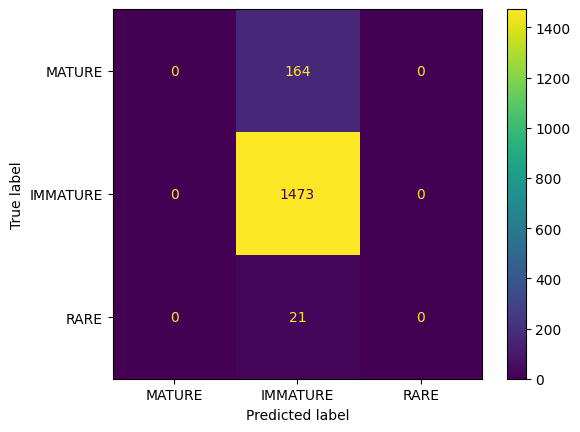

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       164
           1       0.89      1.00      0.94      1473
           2       0.00      0.00      0.00        21

    accuracy                           0.89      1658
   macro avg       0.30      0.33      0.31      1658
weighted avg       0.79      0.89      0.84      1658

STEP 11 DONE



c:\wbc\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\wbc\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\wbc\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
print("STEP 11: Validation (Phase A)")

val_loader.reset()

y_pred_probs = model.predict(val_loader)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_loader.classes

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["MATURE", "IMMATURE", "RARE"]
)
disp.plot()
plt.show()

print(classification_report(y_true, y_pred))
print("STEP 11 DONE\n")

In [31]:
print("STEP 12: Rebuild model for full-data training (Phase B)")

base_model_full = EfficientNetB1(
    weights="imagenet",
    include_top=False,
    input_shape=(240,240,3)
)

base_model_full.trainable = False  # keep frozen initially

x = base_model_full.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(3, activation="softmax")(x)

model_full = models.Model(inputs=base_model_full.input, outputs=output)

model_full.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("STEP 12 DONE\n")

STEP 12: Rebuild model for full-data training (Phase B)
STEP 12 DONE



In [32]:
print("STEP 12: Rebuild model for full-data training (Phase B)")

base_model_full = EfficientNetB1(
    weights="imagenet",
    include_top=False,
    input_shape=(240,240,3)
)

base_model_full.trainable = False  # keep frozen initially

x = base_model_full.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(3, activation="softmax")(x)

model_full = models.Model(inputs=base_model_full.input, outputs=output)

model_full.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("STEP 12 DONE\n")

STEP 12: Rebuild model for full-data training (Phase B)
STEP 12 DONE



In [33]:
print("STEP 13: Class weights (FULL data)")

classes_full = np.unique(train_df["label3"])

weights_full = compute_class_weight(
    class_weight="balanced",
    classes=classes_full,
    y=train_df["label3"]
)

class_weights_full = dict(zip(classes_full, weights_full))

print(class_weights_full)
print("STEP 13 DONE\n")

STEP 13: Class weights (FULL data)
{'IMMATURE': np.float64(3.3691056910569106), 'MATURE': np.float64(0.37515842839036756), 'RARE': np.float64(26.564102564102566)}
STEP 13 DONE



In [34]:
print("STEP 14: Full-data generator")

full_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

full_loader = full_gen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="label3",
    target_size=(240,240),
    class_mode="categorical",
    batch_size=32,
    shuffle=True
)

print("STEP 14 DONE\n")

STEP 14: Full-data generator
Found 8288 validated image filenames belonging to 3 classes.
STEP 14 DONE

